In [3]:
import pandas as pd
import tldextract
import matplotlib.pyplot as plt
import seaborn as sns
import json



In [4]:
df_cookie = pd.read_csv("backups/main_javascript_cookies.csv")
df_request =  pd.read_csv("backups/main_request.csv")
df_javascript = pd.read_csv("backups/main_javascript.csv")

/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/1984377474.py:2: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_request =  pd.read_csv("backups/main_request.csv")


In [5]:
# Extract domain for cookie,request, and script
df_cookie['domain_cookie'] = df_cookie['host_url'].apply(lambda url: tldextract.extract(url).registered_domain)

df_request['domain_url'] = df_request['host_url'].apply(lambda url: tldextract.extract(url).registered_domain)

df_javascript['domain_script_url'] = df_javascript['host_url'].apply(
    lambda url: tldextract.extract(str(url)).registered_domain if pd.notnull(url) else None
)

/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/3513479596.py:2: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  df_cookie['domain_cookie'] = df_cookie['host_url'].apply(lambda url: tldextract.extract(url).registered_domain)
/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/3513479596.py:4: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  df_request['domain_url'] = df_request['host_url'].apply(lambda url: tldextract.extract(url).registered_domain)
/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/3513479596.py:7: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major 

In [6]:
# Get stage of data collection process
df_cookie = df_cookie[df_cookie["clicked"]!="nan"]
df_cookie["clicked_stage"] = df_cookie["stage"] + " (" + df_cookie["clicked"].str.capitalize() + ")"

df_request = df_request[df_request["clicked"]!="nan"]
df_request["clicked_stage"] = df_request["stage"] + " (" + df_request["clicked"].str.capitalize() + ")"

df_javascript = df_javascript[df_javascript["clicked"]!="nan"]
df_javascript["clicked_stage"] = df_javascript["stage"] + " (" + df_javascript["clicked"].str.capitalize() + ")"

In [7]:
# Load the lisst of Categories of trackers, grooup trackers by 9 categories
# https://disconnect.me/trackerprotection
with open('dataset_disconnect/services-relay-disconnect.json', 'r', encoding='utf-8') as f:
    json_data = json.load(f)

# Extract the domains belong to FingerprintingInvasive and FingerprintingGeneral category
fp_invasive_domains = set(json_data.get("categories", {}).get("FingerprintingInvasive", []))
fp_general_domains = set(json_data.get("categories", {}).get("FingerprintingGeneral", []))


# Create boolean columns in the df_javascript for FingerprintingInvasive and FingerprintingGeneral category for each script
df_javascript['FingerprintingInvasive'] = df_javascript['domain_script_url'].isin(fp_invasive_domains)
df_javascript['FingerprintingGeneral'] = df_javascript['domain_script_url'].isin(fp_general_domains)



In [10]:
with open('banner_analysis/disclosure_type_update_1105/vague_disclosure.txt', 'r') as file:
     vague_disclosure = [line.strip() for line in file.readlines()]
with open('banner_analysis/disclosure_type_update_1105/cookie_only_disclosure.txt', 'r') as file:
    cookie_only_disclosure = [line.strip() for line in file.readlines()]

with open('banner_analysis/disclosure_type_update_1105/cookie_only_and_vague_disclosure.txt', 'r') as file:
    cookie_only_and_vague_disclosure = [line.strip() for line in file.readlines()]

with open('banner_analysis/disclosure_type_update_1105/broad_disclosure.txt', 'r') as file:
    broad_disclosure = [line.strip() for line in file.readlines()]
    

with open('banner_analysis/unique_domains_can_analyze_banner.csv', 'r') as file:
    unique_domains_can_analyze_banner = [line.strip() for line in file.readlines()]

In [ ]:
df_javascript_accept_1 = df_javascript[df_javascript['clicked_stage'].isin([
    'Before Interaction (Accept)',
    'After Interaction (Accept)',
    'After Reload (Accept)'
])]

df_javascript_reject_1 = df_javascript_accept_1[
    (df_javascript_accept_1['AllList'] == True) & 
    ((df_javascript_accept_1['FingerprintingInvasive'] == True) | (df_javascript_accept_1['FingerprintingGeneral'] == True)) & 
    (df_javascript_accept_1['domain_script_url'] != df_javascript_accept_1['domain']) &
    (df_javascript_reject['domain_script_url'].isin(disconnect_domains))
]

df_javascript_reject_1["symbol"].unique()

browser_info_symbols = [
    'window.navigator.userAgent',
    'window.navigator.language',
    'window.navigator.platform',
    'window.navigator.maxTouchPoints',
    'window.navigator.plugins',
    'window.navigator.javaEnabled',
    'window.navigator.toString',
    'window.navigator.hardwareConcurrency',
    'window.navigator.webdriver',
    'window.navigator.oscpu',
    'window.navigator.appVersion',
    'window.navigator.cookieEnabled',
    'window.navigator.appCodeName',
    'window.navigator.appName',
    'window.navigator.product',
    'window.navigator.doNotTrack',
    'window.navigator.globalPrivacyControl',
    'window.navigator.buildID',
    'window.navigator.productSub',
    'window.navigator.credentials',
    'window.navigator.vendor',
    'window.navigator.wakeLock',
    'window.navigator.hasOwnProperty',
    'window.navigator.mimeTypes',
    'window.navigator.sendBeacon',
    'window.navigator.permissions',
    'window.navigator.getGamepads',
    'window.navigator.languages',
    'window.navigator.serviceWorker',
    'window.navigator.geolocation',
    'window.navigator.onLine',
    'window.navigator.userActivation',
    'window.navigator.pdfViewerEnabled',
    'window.navigator.mediaCapabilities',
    'window.navigator.vendorSub',
    'window.navigator.mediaDevices',
    'window.navigator.clipboard',
    'window.navigator.mediaSession',
    'window.navigator.locks',
    'window.navigator.storage',
    'window.navigator.requestMediaKeySystemAccess',
    'window.navigator.__proto__'
]

# Screen and Display Information
screen_display_info_symbols = [
    'window.screen.colorDepth',
    'window.screen.pixelDepth'
]

# # Local and Session Storage
# storage_info_symbols = [
#     'window.localStorage',
#     'window.sessionStorage',
#     'window.document.cookie',

#     'Storage.getItem',
#     'Storage.setItem',
#     'Storage.removeItem',
#     'Storage.clear',
#     'Storage.length',
#     'Storage.key',
#     'Storage.toString',
#     'Storage.hasOwnProperty'
# ]

# # Document Information
# document_info_symbols = [
#     'window.document.referrer',
#     'window.document.cookie',
#     'window.name'
# ]

# # HTML Canvas (for canvas fingerprinting)
# html_canvas_info_symbols = [
#     'HTMLCanvasElement.getContext',
#     'HTMLCanvasElement.width',
#     'HTMLCanvasElement.height',
#     'HTMLCanvasElement.toDataURL',
#     'HTMLCanvasElement.addEventListener',
#     'HTMLCanvasElement.tagName',
#     'HTMLCanvasElement.setAttribute',
#     'HTMLCanvasElement.style',
#     'HTMLCanvasElement.toString',
#     'CanvasRenderingContext2D.imageSmoothingEnabled',
#     'CanvasRenderingContext2D.globalCompositeOperation',
#     'CanvasRenderingContext2D.miterLimit',
#     'CanvasRenderingContext2D.filter',
#     'CanvasRenderingContext2D.lineCap',
#     'CanvasRenderingContext2D.lineDashOffset',
#     'CanvasRenderingContext2D.lineJoin',
#     'CanvasRenderingContext2D.font',
#     'CanvasRenderingContext2D.lineWidth',
#     'CanvasRenderingContext2D.setLineDash',
#     'CanvasRenderingContext2D.shadowColor',
#     'CanvasRenderingContext2D.shadowOffsetX',
#     'CanvasRenderingContext2D.shadowOffsetY',
#     'CanvasRenderingContext2D.rotate',
#     'CanvasRenderingContext2D.fillStyle',
#     'CanvasRenderingContext2D.hasOwnProperty',
#     'CanvasRenderingContext2D.measureText',
#     'CanvasRenderingContext2D.textAlign',
#     'CanvasRenderingContext2D.textBaseline',
#     'CanvasRenderingContext2D.fillText',
#     'CanvasRenderingContext2D.save',
#     'CanvasRenderingContext2D.restore',
#     'CanvasRenderingContext2D.shadowBlur',
#     'CanvasRenderingContext2D.strokeStyle',
#     'CanvasRenderingContext2D.ellipse',
#     'CanvasRenderingContext2D.fill',
#     'CanvasRenderingContext2D.stroke',
#     'CanvasRenderingContext2D.rect',
#     'CanvasRenderingContext2D.isPointInPath',
#     'CanvasRenderingContext2D.arc',
#     'CanvasRenderingContext2D.fillRect',
#     'CanvasRenderingContext2D.createLinearGradient',
#     'CanvasRenderingContext2D.createRadialGradient',
#     'CanvasRenderingContext2D.strokeText',
#     'CanvasRenderingContext2D.getImageData',
#     'CanvasRenderingContext2D.bezierCurveTo'
# ]
# # WebRTC (for IP address leakage)
# webrtc_info_symbols = [
#     'RTCPeerConnection.createDataChannel',
#     'RTCPeerConnection.createOffer',
#     'RTCPeerConnection.onicecandidate',
#     'RTCPeerConnection.setLocalDescription',
#     'RTCPeerConnection.addEventListener',
#     'RTCPeerConnection.removeEventListener',
#     'RTCPeerConnection.close',
#     'RTCPeerConnection.toString'
# ]
# Offline Audio Context (for audio fingerprinting)
audio_fingerprinting_symbols = [
    # Audio Contexts
    'AudioContext',
    'AudioContext.createOscillator',
    'AudioContext.createAnalyser',
    'AudioContext.createGain',
    'AudioContext.createScriptProcessor',
    'AudioContext.createDynamicsCompressor',
    'AudioContext.createBiquadFilter',
    'AudioContext.destination',
    'AudioContext.sampleRate',
    'AudioContext.currentTime',
    'AudioContext.state',
    'AudioContext.listener',
    'AudioContext.resume',

     # Offline Audio Context
    'OfflineAudioContext',
    'OfflineAudioContext.createOscillator',
    'OfflineAudioContext.destination',
    'OfflineAudioContext.createDynamicsCompressor',
    'OfflineAudioContext.oncomplete',
    'OfflineAudioContext.startRendering',
    'OfflineAudioContext.state',
    'OfflineAudioContext.createAnalyser',
    'OfflineAudioContext.createBiquadFilter',
    'OfflineAudioContext.listener',
    'OfflineAudioContext.addEventListener',
    # Audio Nodes
    'OscillatorNode',
    'OscillatorNode.type',
    'OscillatorNode.frequency',
    'OscillatorNode.detune',
    'OscillatorNode.start',
    'OscillatorNode.stop',
    'OscillatorNode.connect',
    'OscillatorNode.disconnect',

    #gain Node
    'GainNode',
    'GainNode.gain',
    'GainNode.connect',


    'ScriptProcessorNode',
    'ScriptProcessorNode.onaudioprocess',

    'AnalyserNode',
    'AnalyserNode.fftSize',
    'AnalyserNode.frequencyBinCount',
    'AnalyserNode.minDecibels',
    'AnalyserNode.maxDecibels',
    'AnalyserNode.smoothingTimeConstant',
    'AnalyserNode.getFloatFrequencyData',  # Frequency analysis
    'AnalyserNode.getByteFrequencyData',
    'AnalyserNode.getFloatTimeDomainData',  # Time domain analysis
    'AnalyserNode.getByteTimeDomainData',
    'AnalyserNode.channelCount',
    'AnalyserNode.channelCountMode',
    'AnalyserNode.channelInterpretation',
    'AnalyserNode.context',
    'AnalyserNode.numberOfInputs',
    'AnalyserNode.numberOfOutputs',

]

# Dictionary of all categories
symbol_categories = {
    'Screen/Display Fingerprinting': screen_display_info_symbols,
    'Audio Fingerprinting': audio_fingerprinting_symbols,
    'Font Fingerprinting': font_enumeration_symbols,
    'Media I/O fingerprinting': media_devices_symbols,
    'DOM Layout Fingerprinting': element_layout_symbols,
    'keystroke Fingerprinting': keyboard_input_symbols,
    'Cross-Context Communication Fingerprinting': communication_symbols,
    # 'Permissions & User Preferences': permission_preference_symbols
}

# Add to WebRTC
# webrtc_info_symbols.append('RTCPeerConnection.iceGatheringState')

# Add to Canvas Fingerprinting
# html_canvas_info_symbols.append('HTMLCanvasElement.children')

# Map each symbol to its category
def get_symbol_category(symbol):
    for category, symbol_list in symbol_categories.items():
        if symbol in symbol_list:
            return category
    return 'Other'

# Add a new column for symbol category
df_javascript_reject_1['symbol_category'] = df_javascript_reject_1['symbol'].map(get_symbol_category)

other_symbols = (
    df_javascript_reject_1[df_javascript_reject_1['symbol_category'] == 'Other']['symbol']
    .unique()
)

print(other_symbols)
# Count unique domains per category
category_site_counts = (
    df_javascript_reject_1
    .groupby('symbol_category')['domain']
    .nunique()
    .reset_index(name='unique_site_count')
    .sort_values(by='unique_site_count', ascending=False)
)

# Display the result
print(category_site_counts)

[]
         symbol_category  unique_site_count
2          Document Info               3260
0           Browser Info               3135
3           Storage Info               1779
1  Canvas Fingerprinting                 83
4                 WebRTC                 29


/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/1783395164.py:206: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_javascript_reject_1['symbol_category'] = df_javascript_reject_1['symbol'].map(get_symbol_category)


In [12]:
from collections import Counter

# Define colors for the groups (extend if using 4)
colors = ['#78C850', '#F08030', '#6890F0', '#F8D030']

# Step 1: Filter cookie data for relevant stages and tracking cookies
df_cookie_reject = df_cookie[df_cookie['clicked_stage'].isin([
    'Before Interaction (Reject)',
    'After Interaction (Reject)',
    'After Reload (Reject)'
])]
df_cookie_reject = df_cookie_reject[
    (df_cookie_reject['is_tracking'] == True) &
    (df_cookie_reject['domain_cookie'] != df_cookie_reject['domain'])
]

# Step 2: Assign disclosure group to each domain
def assign_disclosure_group(domain):
    if domain in cookie_only_and_vague_disclosure:
        return 'Cookie-only and vague disclosure'
    elif domain in cookie_only_disclosure:
        return 'Cookie-only disclosure'
    elif domain in vague_disclosure:
        return 'Vague disclosure'
    elif domain in broad_disclosure:
        return 'Broad disclosure'
    else:
        return None

# Step 2: Get domains with tracking cookies after Reject
domains_with_tracking = set(df_cookie_reject['domain'])

# Step 3: Domains without tracking cookies after Reject
domains_without_tracking = set(unique_domains_can_analyze_banner) - domains_with_tracking

# Step 4: Define the disclosure group assignment function
def assign_disclosure_group(domain):
    if domain in cookie_only_and_vague_disclosure:
        return 'Cookie-only and vague disclosure'
    elif domain in cookie_only_disclosure:
        return 'Cookie-only disclosure'
    elif domain in vague_disclosure:
        return 'Vague disclosure'
    elif domain in broad_disclosure:
        return 'Broad disclosure'
    else:
        return 'Uncategorized'

# Step 5: Assign disclosure groups to these domains
group_counts = Counter(assign_disclosure_group(domain) for domain in domains_without_tracking)

# Step 6: Print results
print("Number of sites with no tracking cookies after Reject, grouped by disclosure type:")
for group, count in group_counts.items():
    print(f"{group}: {count}")

# Step 1: Filter request data for relevant stages and matching requests
df_request_reject = df_request[df_request['clicked_stage'].isin([
    'Before Interaction (Reject)',
    'After Interaction (Reject)',
    'After Reload (Reject)'
])]
df_request_reject = df_request_reject[
    (df_request_reject['AllList'] == True) &
    (df_request_reject['domain_url'] != df_request_reject['domain'])
]

Number of sites with no tracking cookies after Reject, grouped by disclosure type:
Broad disclosure: 867
Cookie-only disclosure: 1267
Cookie-only and vague disclosure: 762
Vague disclosure: 26


In [302]:
from collections import Counter, defaultdict

# Load analyzable domain list
common_domains = set(unique_domains_can_analyze_banner)

# Step 1: Get domains with tracking cookies after Reject
df_cookie_reject = df_cookie[df_cookie['clicked_stage'].isin([
    'Before Interaction (Reject)',
    'After Interaction (Reject)',
    'After Reload (Reject)'
])]
df_cookie_reject = df_cookie_reject[
    (df_cookie_reject['is_tracking'] == True) &
    (df_cookie_reject['domain_cookie'] != df_cookie_reject['domain'])
]
domains_with_tracking_cookies = set(df_cookie_reject['domain'])

# Step 2: Get domains with third-party tracking requests after Reject

df_request_reject = df_request[df_request['clicked_stage'].isin([
    'Before Interaction (Reject)',
    'After Interaction (Reject)',
    'After Reload (Reject)'
])]

df_request_tracking_reject = df_request_reject[
    (df_request_reject['AllList'] == True) &
    (df_request_reject['domain_url'] != df_request_reject['domain'])
]
domains_with_tracking_requests = set(df_request_tracking_reject['domain'])

# Step 3: Domains that have no tracking cookies
domains_without_tracking_cookies = common_domains - domains_with_tracking_cookies
print(len(domains_without_tracking_cookies))


# Step 4: Filter to those that still have tracking requests
domains_with_requests_only = domains_without_tracking_cookies & domains_with_tracking_requests

# Step 5: Assign disclosure group
def assign_disclosure_group(domain):
    if domain in cookie_only_and_vague_disclosure:
        return 'Cookie-only and vague disclosure'
    elif domain in cookie_only_disclosure:
        return 'Cookie-only disclosure'
    elif domain in vague_disclosure:
        return 'Vague disclosure'
    elif domain in broad_disclosure:
        return 'Broad disclosure'
    else:
        return 'Uncategorized'
# Step 6: Group domains by disclosure type
grouped_domains_xx = defaultdict(list)
for domain in domains_without_tracking_cookies:
    group = assign_disclosure_group(domain)
    grouped_domains_xx[group].append(domain)

# Step X5: Print counts
print("\nXX:")
for group in ['Broad disclosure', 'Vague disclosure', 'Cookie-only disclosure', 'Cookie-only and vague disclosure', 'Uncategorized']:
    count = len(grouped_domains_xx[group])
    print(f"{group}: {count}")

# Step 6: Group domains by disclosure type
grouped_domains = defaultdict(list)
for domain in domains_with_requests_only:
    group = assign_disclosure_group(domain)
    grouped_domains[group].append(domain)

# Step 7: Print results
# print("\nSites with tracking requests but no tracking cookies after Reject, grouped by disclosure type:")
# for group, domains in grouped_domains.items():
#     print(f"{group}: {len(domains)} sites")
#     for d in sorted(domains):
#         print(f"  - {d}")
# Step 7: Print summary counts
print("\nNumber of sites with tracking requests but no tracking cookies after Reject, grouped by disclosure type:")
for group in ['Broad disclosure', 'Vague disclosure', 'Cookie-only disclosure', 'Cookie-only and vague disclosure', 'Uncategorized']:
    count = len(grouped_domains[group])
    print(f"{group}: {count}")


# Step X1: Filter fingerprinting scripts after Accept stages (as you defined)
df_javascript_reject = df_javascript[df_javascript['clicked_stage'].isin([
    'Before Interaction (Reject)',
    'After Interaction (Reject)',
    'After Reload (Reject)'
])]
df_javascript_reject = df_javascript_reject[
    (df_javascript_reject['AllList'] == True) & 
    ((df_javascript_reject['FingerprintingInvasive'] == True) | (df_javascript_reject['FingerprintingGeneral'] == True)) & 
    (df_javascript_reject['domain_script_url'] != df_javascript_reject['domain'])
]

# Step X2: Get domains with JavaScript-based fingerprinting
domains_with_fingerprinting_scripts = set(df_javascript_reject['domain'])

# Step X3: Intersect with domains that have no tracking cookies
domains_with_scripts_only = domains_without_tracking_cookies & domains_with_fingerprinting_scripts

# Step X4: Group by disclosure type
grouped_script_domains = defaultdict(list)
for domain in domains_with_scripts_only:
    group = assign_disclosure_group(domain)
    grouped_script_domains[group].append(domain)

# Step X5: Print counts
print("\nNumber of sites with fingerprinting scripts but no tracking cookies after Reject, grouped by disclosure type:")
for group in ['Broad disclosure', 'Vague disclosure', 'Cookie-only disclosure', 'Cookie-only and vague disclosure', 'Uncategorized']:
    count = len(grouped_script_domains[group])
    print(f"{group}: {count}")


2939

XX:
Broad disclosure: 867
Vague disclosure: 30
Cookie-only disclosure: 1276
Cookie-only and vague disclosure: 766
Uncategorized: 0

Number of sites with tracking requests but no tracking cookies after Reject, grouped by disclosure type:
Broad disclosure: 825
Vague disclosure: 26
Cookie-only disclosure: 1191
Cookie-only and vague disclosure: 698
Uncategorized: 0

Number of sites with fingerprinting scripts but no tracking cookies after Reject, grouped by disclosure type:
Broad disclosure: 544
Vague disclosure: 8
Cookie-only disclosure: 344
Cookie-only and vague disclosure: 131
Uncategorized: 0


In [14]:
# Step 1: Load JSON
json_file_path = '/Users/hadao/Downloads/Archive/services-relay-disconnect.json'
with open(json_file_path, 'r') as f:
    json_data = json.load(f)

# Step 2: Define desired categories
selected_categories = [
    "Email",
    "EmailAggressive",
    "Advertising",
    "Analytics",
    "FingerprintingInvasive",
    "FingerprintingGeneral",
    "Anti-fraud",
    "Social",
    "Cryptomining"
]

# Step 3: Collect all third-party domains under these categories
disconnect_domains = set()
for category, domains in json_data.get("categories", {}).items():
    if category in selected_categories:
        disconnect_domains.update(domains)

In [33]:
df_cookie = df_cookie[df_cookie["clicked"]!="nan"]
df_cookie["clicked_stage"] = df_cookie["stage"] + " (" + df_cookie["clicked"].str.capitalize() + ")"

# df_request['domain_url'] = df_request['host_url'].apply(lambda url: tldextract.extract(url).registered_domain)

df_request = df_request[df_request["clicked"]!="nan"]
df_request["clicked_stage"] = df_request["stage"] + " (" + df_request["clicked"].str.capitalize() + ")"

df_javascript = df_javascript[df_javascript["clicked"]!="nan"]
df_javascript["clicked_stage"] = df_javascript["stage"] + " (" + df_javascript["clicked"].str.capitalize() + ")"

In [8]:
# Step 1: Load the JSON file
import json
with open('/Users/hadao/Downloads/Archive/services-relay-disconnect.json', 'r', encoding='utf-8') as f:
    json_data = json.load(f)

# Step 2: Extract the domain lists from JSON
fp_invasive_domains = set(json_data.get("categories", {}).get("FingerprintingInvasive", []))
fp_general_domains = set(json_data.get("categories", {}).get("FingerprintingGeneral", []))


# Step 5: Create boolean columns
df_javascript['FingerprintingInvasive'] = df_javascript['domain_script_url'].isin(fp_invasive_domains)
df_javascript['FingerprintingGeneral'] = df_javascript['domain_script_url'].isin(fp_general_domains)

# Optional: View result
print(df_javascript[['domain', 'domain_script_url', 'FingerprintingInvasive', 'FingerprintingGeneral']])


             domain      domain_script_url  FingerprintingInvasive  \
0       plosone.org               plos.org                   False   
1       plosone.org               plos.org                   False   
2       plosone.org               plos.org                   False   
3       plosone.org               plos.org                   False   
4       plosone.org  googlesyndication.com                   False   
...             ...                    ...                     ...   
486975   dexcom.com          qualtrics.com                   False   
486976   dexcom.com          qualtrics.com                   False   
486977   dexcom.com             dexcom.com                   False   
486978   dexcom.com           omappapi.com                   False   
486979   dexcom.com             dexcom.com                   False   

        FingerprintingGeneral  
0                       False  
1                       False  
2                       False  
3                       False  

In [10]:
# Filter the dataframe for each stage in df_cookie
df_before_interaction_cookie = df_cookie[df_cookie['clicked_stage'] == 'Before Interaction (Reject)']
df_after_interaction_cookie = df_cookie[df_cookie['clicked_stage'] == 'After Interaction (Reject)']
df_after_reload_cookie = df_cookie[df_cookie['clicked_stage'] == 'After Reload (Reject)']

# Get the unique domains for each stage in df_cookie
domains_before_cookie = set(df_before_interaction_cookie['domain'].unique())
domains_after_cookie = set(df_after_interaction_cookie['domain'].unique())
domains_reload_cookie = set(df_after_reload_cookie['domain'].unique())

# Find the union of domains across all three stages in df_cookie
unique_domains_cookie = domains_before_cookie | domains_after_cookie | domains_reload_cookie
print(len(unique_domains_cookie))

4630


In [227]:
with open('/Users/hadao/Downloads/IMC_2025_cookie/banner_analysis/disclosure_type_update_1105/vague_disclosure.txt', 'r') as file:
     vague_disclosure = [line.strip() for line in file.readlines()]

with open('banner_analysis/disclosure_type_update_1105/cookie_only_disclosure.txt', 'r') as file:
    cookie_only_disclosure = [line.strip() for line in file.readlines()]

with open('banner_analysis/disclosure_type_update_1105/cookie_only_and_vague_disclosure.txt', 'r') as file:
    cookie_only_and_vague_disclosure = [line.strip() for line in file.readlines()]
with open('banner_analysis/disclosure_type_update_1105/broad_disclosure.txt', 'r') as file:
    broad_disclosure = [line.strip() for line in file.readlines()]
    

with open('/Users/hadao/Downloads/IMC_2025_cookie/banner_analysis/output_final/unique_domains_can_analyze_banner.csv', 'r') as file:
    unique_domains_can_analyze_banner = [line.strip() for line in file.readlines()]



In [228]:
a = set(vague_disclosure)
b = set (unique_domains_can_analyze_banner)

print (a-b)

print (b-a)

set()
{'objectrocket.com', 'your-storageshare.de', '21vek.by', 'gumtree.com', 'elcorreo.com', 'themezee.com', 'kick.com', 'sunmedia.tv', 'catawiki.com', 'shrm.org', 'mercer.com', 'emojicombos.com', 'optimicdn.com', 'prismhr.com', 'lilystyle.ai', 'ukri.org', 'worldtimeserver.com', 'a1.by', 'word.tips', 'linkvertise.com', 'serebii.net', 'newsmemory.com', 'kompas.tv', 'le10sport.com', 'google.dm', 'admitad.com', 'hasbro.com', 'plotek.pl', 'answerthepublic.com', 'epicurious.com', 'smule.com', 'fronius.com', 'wordunscrambler.net', 'flashscore.it', 'google.mw', 'cnews.fr', 'ccma.cat', 'nextdoor.com', 'therange.co.uk', 'theinformation.com', 'zoom.com.br', 'wufoo.com', 'mackolik.com', 'yallakora.com', 'ddnss.de', 'marmiton.org', 'tuya.com', 'check24.de', 'rec.net', 'su89-cdn.net', 'google.is', 'fashion-press.net', 'kuruma-news.jp', 'carecredit.com', 'rocketcyber.com', '3u.net', 'kilat.com', 'cheezburger.com', 'rsc.org', 'ralphlauren.com', 'cloudlinux.com', 'xataka.com', 'pensador.com', 'ea.com

In [303]:
from collections import Counter

# Define colors for the groups (extend if using 4)
colors = ['#78C850', '#F08030', '#6890F0', '#F8D030']

# Step 1: Filter cookie data for relevant stages and tracking cookies
df_cookie_reject = df_cookie[df_cookie['clicked_stage'].isin([
    'Before Interaction (Reject)',
    'After Interaction (Reject)',
    'After Reload (Reject)'
])]
df_cookie_reject = df_cookie_reject[
    (df_cookie_reject['is_tracking'] == True) &
    (df_cookie_reject['domain_cookie'] != df_cookie_reject['domain'])
]

# Step 2: Assign disclosure group to each domain
def assign_disclosure_group(domain):
    if domain in cookie_only_and_vague_disclosure:
        return 'Cookie-only and vague disclosure'
    elif domain in cookie_only_disclosure:
        return 'Cookie-only disclosure'
    elif domain in vague_disclosure:
        return 'Vague disclosure'
    elif domain in broad_disclosure:
        return 'Broad disclosure'
    else:
        return None

# Step 1: Load the list of common domains
common_domains_df = pd.read_csv("/Users/hadao/Downloads/Archive/hichic_update_banner_sqlite.csv")
common_domains = set(common_domains_df['domain'].str.strip())  # Clean up whitespace

# Step 2: Get domains with tracking cookies after Reject
domains_with_tracking = set(df_cookie_reject['domain'])

# Step 3: Domains without tracking cookies after Reject
domains_without_tracking = common_domains - domains_with_tracking

# Step 4: Define the disclosure group assignment function
def assign_disclosure_group(domain):
    if domain in cookie_only_and_vague_disclosure:
        return 'Cookie-only and vague disclosure'
    elif domain in cookie_only_disclosure:
        return 'Cookie-only disclosure'
    elif domain in vague_disclosure:
        return 'Vague disclosure'
    elif domain in broad_disclosure:
        return 'Broad disclosure'
    else:
        return 'Uncategorized'

# Step 5: Assign disclosure groups to these domains
group_counts = Counter(assign_disclosure_group(domain) for domain in domains_without_tracking)

# Step 6: Print results
print("Number of sites with no tracking cookies after Reject, grouped by disclosure type:")
for group, count in group_counts.items():
    print(f"{group}: {count}")

# Step 1: Filter request data for relevant stages and matching requests
df_request_reject = df_request[df_request['clicked_stage'].isin([
    'Before Interaction (Reject)',
    'After Interaction (Reject)',
    'After Reload (Reject)'
])]
df_request_reject = df_request_reject[
    (df_request_reject['AllList'] == True) &
    (df_request_reject['domain_url'] != df_request_reject['domain'])
]


Number of sites with no tracking cookies after Reject, grouped by disclosure type:
Broad disclosure: 765
Cookie-only disclosure: 1186
Cookie-only and vague disclosure: 718
Uncategorized: 36
Vague disclosure: 23


In [18]:
# Step 1: Load JSON
json_file_path = '/Users/hadao/Downloads/Archive/services-relay-disconnect.json'
with open(json_file_path, 'r') as f:
    json_data = json.load(f)

# Step 2: Define desired categories
selected_categories = [
    "Email",
    "EmailAggressive",
    "Advertising",
    "Analytics",
    "FingerprintingInvasive",
    "FingerprintingGeneral",
    "Anti-fraud",
    "Social",
    "Cryptomining"
]

# Step 3: Collect all third-party domains under these categories
disconnect_domains = set()
for category, domains in json_data.get("categories", {}).items():
    if category in selected_categories:
        disconnect_domains.update(domains)

In [304]:

# Step 1: Get domains with tracking cookies after Reject
df_cookie_reject = df_cookie[df_cookie['clicked_stage'].isin([
    'Before Interaction (Reject)',
    'After Interaction (Reject)',
    'After Reload (Reject)'
])]
df_cookie_reject = df_cookie_reject[
    (df_cookie_reject['is_tracking'] == True) &
    (df_cookie_reject['domain_cookie'] != df_cookie_reject['domain']) & 
    (df_cookie_reject['domain_cookie'].isin(disconnect_domains))
]
domains_with_tracking_cookies = set(df_cookie_reject['domain'])

# Step 2: Get domains with third-party tracking requests after Reject

df_request_reject = df_request[df_request['clicked_stage'].isin([
    'Before Interaction (Reject)',
    'After Interaction (Reject)',
    'After Reload (Reject)'
])]

df_request_tracking_reject = df_request_reject[
    (df_request_reject['AllList'] == True) &
    (df_request_reject['domain_url'] != df_request_reject['domain']) &
    (df_request_reject['domain_url'].isin(disconnect_domains))
]
domains_with_tracking_requests = set(df_request_tracking_reject['domain'])

# Step 3: Domains that have no tracking cookies
domains_without_tracking_cookies = common_domains - domains_with_tracking_cookies
print(len(domains_without_tracking_cookies))


# Step 4: Filter to those that still have tracking requests
domains_with_requests_only = domains_without_tracking_cookies & domains_with_tracking_requests

# Step 5: Assign disclosure group
def assign_disclosure_group(domain):
    if domain in cookie_only_and_vague_disclosure:
        return 'Cookie-only and vague disclosure'
    elif domain in cookie_only_disclosure:
        return 'Cookie-only disclosure'
    elif domain in vague_disclosure:
        return 'Vague disclosure'
    elif domain in broad_disclosure:
        return 'Broad disclosure'
    else:
        return 'Uncategorized'
# Step 6: Group domains by disclosure type
grouped_domains_xx = defaultdict(list)
for domain in domains_without_tracking_cookies:
    group = assign_disclosure_group(domain)
    grouped_domains_xx[group].append(domain)

# Step X5: Print counts
print("\nNumber of sites with no tracking cookies:")
for group in ['Broad disclosure', 'Vague disclosure', 'Cookie-only disclosure', 'Cookie-only and vague disclosure', 'Uncategorized']:
    count = len(grouped_domains_xx[group])
    print(f"{group}: {count}")

# Step 6: Group domains by disclosure type
grouped_domains = defaultdict(list)
for domain in domains_with_requests_only:
    group = assign_disclosure_group(domain)
    grouped_domains[group].append(domain)

# Step 7: Print results
# print("\nSites with tracking requests but no tracking cookies after Reject, grouped by disclosure type:")
# for group, domains in grouped_domains.items():
#     print(f"{group}: {len(domains)} sites")
#     for d in sorted(domains):
#         print(f"  - {d}")
# Step 7: Print summary counts
print("\nNumber of sites with tracking requests but no tracking cookies after Reject, grouped by disclosure type:")
for group in ['Broad disclosure', 'Vague disclosure', 'Cookie-only disclosure', 'Cookie-only and vague disclosure', 'Uncategorized']:
    count = len(grouped_domains[group])
    print(f"{group}: {count}")


# Step X1: Filter fingerprinting scripts after Accept stages (as you defined)
df_javascript_reject = df_javascript[df_javascript['clicked_stage'].isin([
    'Before Interaction (Accept)',
    'After Interaction (Accept)',
    'After Reload (Accept)'
])]
df_javascript_reject = df_javascript_reject[
    (df_javascript_reject['AllList'] == True) & 
    ((df_javascript_reject['FingerprintingInvasive'] == True) | (df_javascript_reject['FingerprintingGeneral'] == True)) & 
    (df_javascript_reject['domain_script_url'] != df_javascript_reject['domain']) &
    (df_javascript_reject['domain_script_url'].isin(disconnect_domains))
]


# Step X2: Get domains with JavaScript-based fingerprinting
domains_with_fingerprinting_scripts = set(df_javascript_reject['domain'])

# Step X3: Intersect with domains that have no tracking cookies
domains_with_scripts_only = domains_without_tracking_cookies & domains_with_fingerprinting_scripts

# Step X4: Group by disclosure type
grouped_script_domains = defaultdict(list)
for domain in domains_with_scripts_only:
    group = assign_disclosure_group(domain)
    grouped_script_domains[group].append(domain)

# Step X5: Print counts
print("\nNumber of sites with fingerprinting scripts but no tracking cookies after Reject, grouped by disclosure type:")
for group in ['Broad disclosure', 'Vague disclosure', 'Cookie-only disclosure', 'Cookie-only and vague disclosure', 'Uncategorized']:
    count = len(grouped_script_domains[group])
    print(f"{group}: {count}")


2813

Number of sites with no tracking cookies:
Broad disclosure: 805
Vague disclosure: 24
Cookie-only disclosure: 1217
Cookie-only and vague disclosure: 731
Uncategorized: 36

Number of sites with tracking requests but no tracking cookies after Reject, grouped by disclosure type:
Broad disclosure: 757
Vague disclosure: 22
Cookie-only disclosure: 1101
Cookie-only and vague disclosure: 653
Uncategorized: 12

Number of sites with fingerprinting scripts but no tracking cookies after Reject, grouped by disclosure type:
Broad disclosure: 712
Vague disclosure: 14
Cookie-only disclosure: 843
Cookie-only and vague disclosure: 382
Uncategorized: 30


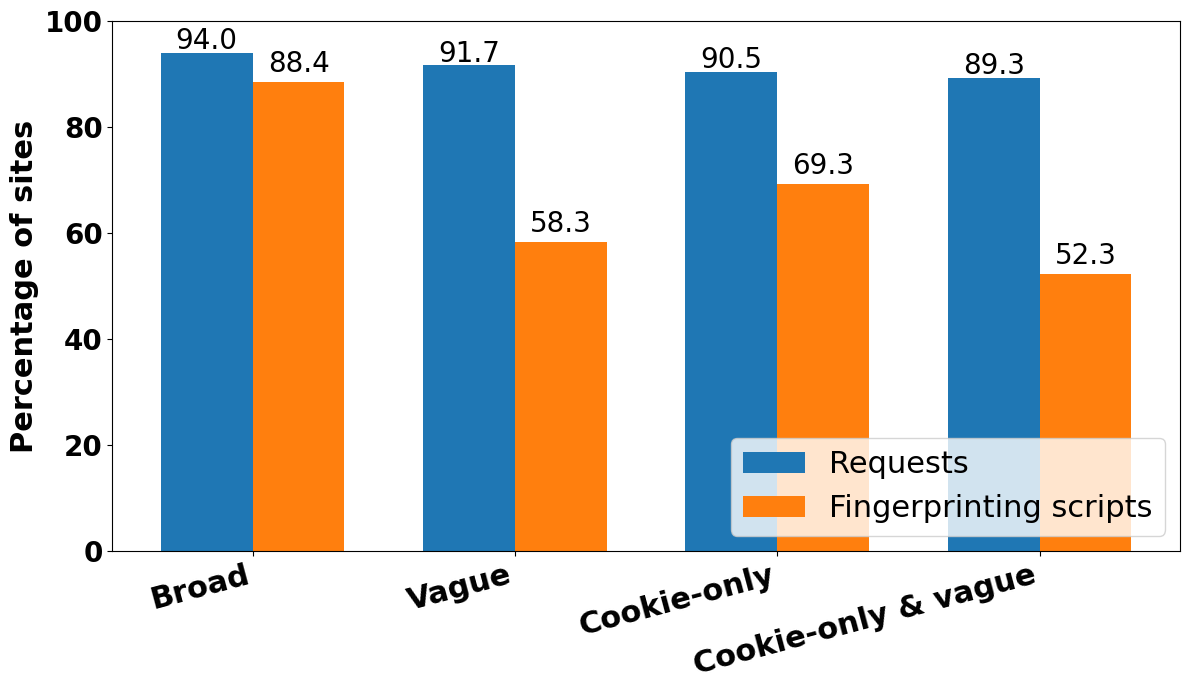

In [305]:
import matplotlib.pyplot as plt
import numpy as np

# Define relevant disclosure groups
disclosure_groups = ['Broad disclosure', 'Vague disclosure', 'Cookie-only disclosure', 'Cookie-only and vague disclosure']

# Count total domains without tracking cookies in each disclosure group
group_total = defaultdict(int)
for domain in domains_without_tracking_cookies:
    group = assign_disclosure_group(domain)
    if group in disclosure_groups:
        group_total[group] += 1

# Calculate request/script percentages relative to domains without cookies in each group
request_percentages = []
script_percentages = []

for group in disclosure_groups:
    total = group_total[group]
    request_count = len(grouped_domains[group])
    script_count = len(grouped_script_domains[group])
    
    request_percent = (request_count / total * 100) if total > 0 else 0
    script_percent = (script_count / total * 100) if total > 0 else 0

    request_percentages.append(request_percent)
    script_percentages.append(script_percent)

# Plotting
x = np.arange(len(disclosure_groups))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, request_percentages, width, label='Requests')
bars2 = ax.bar(x + width/2, script_percentages, width, label='Fingerprinting scripts')

# Add value labels on top of bars (no % symbol)
ax.bar_label(bars1, fmt='%.1f', padding=-2, fontsize=20)
ax.bar_label(bars2, fmt='%.1f', padding=3, fontsize=20)

# Set labels and titles with fontsize
ax.set_ylabel('Percentage of sites', fontsize=22, fontweight='bold')
# ax.set_title('Tracking requests vs fingerprinting scripts\n(no cookies after Reject)', fontsize=16)
ax.set_xticks(x)
ax.set_ylim(0,100)
ax.set_xticklabels(disclosure_groups, rotation=15, fontsize=16, ha = "right")
ax.tick_params(axis='y', labelsize=16)
for label in ax.get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight('bold')
for label in ax.get_xticklabels():
    label.set_fontsize(20)
    label.set_fontweight('bold')
xtick_labels = [
    label.get_text()
    .replace("Cookie-only and vague disclosure", "Cookie-only & vague")
    .replace("Cookie-only disclosure", "Cookie-only")
    .replace("Vague disclosure", "Vague")
    .replace("Broad disclosure", "Broad")
    for label in ax.get_xticklabels()
]
ax.set_xticklabels(xtick_labels, rotation=15, fontsize=22, ha="right")

ax.legend(fontsize=22, loc = 'lower right')
# ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("sites_still_tracking_after_reject.pdf")

plt.show()

In [60]:
# # Step 1: Get domains with tracking cookies after Reject
# df_cookie_reject = df_cookie[df_cookie['clicked_stage'].isin([
#     'Before Interaction (Reject)',
#     'After Interaction (Reject)',
#     'After Reload (Reject)'
# ])]
# df_cookie_reject = df_cookie_reject[
#     (df_cookie_reject['is_tracking'] == True) &
#     (df_cookie_reject['domain_cookie'] != df_cookie_reject['domain'])
# ]
# domains_with_tracking_cookies = set(df_cookie_reject['domain'])

# # Step 2: Get domains with third-party tracking requests after Reject

# df_request_reject = df_request[df_request['clicked_stage'].isin([
#     'Before Interaction (Reject)',
#     'After Interaction (Reject)',
#     'After Reload (Reject)'
# ])]

# df_request_tracking_reject = df_request_reject[
#     (df_request_reject['AllList'] == True) &
#     (df_request_reject['domain_url'] != df_request_reject['domain']) 
#     & (df_request_reject['domain_url'].isin(disconnect_domains))
# ]

# # df_request_tracking_reject = df_request_tracking_reject['domain_url'].isin(disconnect_domains)

# domains_with_tracking_requests = set(df_request_tracking_reject['domain'])

# # Step 3: Domains that have no tracking cookies
# domains_without_tracking_cookies = common_domains - domains_with_tracking_cookies

print(len(domains_without_tracking_cookies))



# Step 4: Filter to those that still have tracking requests
domains_with_requests_only = domains_without_tracking_cookies & domains_with_tracking_requests

# Step 5: Filter requests on domains_with_requests_only
filtered_requests = df_request_tracking_reject[df_request_tracking_reject['domain'].isin(domains_with_requests_only)]



# Step 6: Map each tracking domain_url to the set of first-party domains it appears on
tracking_to_domains = defaultdict(set)
for _, row in filtered_requests.iterrows():
    tracking_to_domains[row['domain_url']].add(row['domain'])

# Step 7: Count how many unique websites each tracking domain appears on
tracking_domain_counts = {tracker: len(domains) for tracker, domains in tracking_to_domains.items()}

# Step 8: Get top 20 tracking domains by number of websites
top_20 = sorted(tracking_domain_counts.items(), key=lambda x: x[1], reverse=True)[:20]

# Step 9: Display in DataFrame
top_20_df = pd.DataFrame(top_20, columns=['Tracking Domain', 'Number of Websites'])
print(top_20_df)
top_20_df.to_csv("top20.csv", index = False)

3022
           Tracking Domain  Number of Websites
0     googletagmanager.com                1944
1     google-analytics.com                1085
2    googlesyndication.com                 921
3          doubleclick.net                 893
4               google.com                 879
5                google.de                 455
6             facebook.net                 353
7             facebook.com                 310
8           googleapis.com                 295
9                licdn.com                 220
10            linkedin.com                 216
11  cloudflareinsights.com                 212
12           cookielaw.org                 183
13              clarity.ms                 166
14        hs-analytics.net                 162
15                bing.com                 149
16              hotjar.com                 148
17             hubspot.com                 147
18             hsforms.com                 141
19           hs-banner.com                 138


In [115]:
# Step 10: Sample 50 host_urls per tracking domain (from different domains)
sampled_host_urls = []

# Ensure we're only working with filtered requests (from relevant domains)
for tracker in top_20_df['Tracking Domain']:
    # Get all requests where this tracker appears
    tracker_requests = filtered_requests[filtered_requests['domain_url'] == tracker]
    
    # Group by first-party domain to ensure uniqueness
    grouped = tracker_requests.groupby('domain')
    
    # From each unique domain, randomly select one host_url
    one_per_domain = grouped.apply(lambda g: g.sample(1)).reset_index(drop=True)
    
    # Randomly pick 50 of them if more than 50 domains exist
    if len(one_per_domain) > 50:
        sampled = one_per_domain.sample(50, random_state=42)
    else:
        sampled = one_per_domain  # if fewer than 50 domains, take all
    
    # Add a column to identify the tracker
    sampled['tracking_domain_url'] = tracker
    
    # Collect the sample
    sampled_host_urls.append(sampled[['tracking_domain_url', 'domain', 'host_url','referrer','headers']])

# Concatenate all samples
final_samples_df = pd.concat(sampled_host_urls, ignore_index=True)

# Save to CSV
final_samples_df.to_csv("top20_sampled_host_urls.csv", index=False)

/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/3588963586.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  one_per_domain = grouped.apply(lambda g: g.sample(1)).reset_index(drop=True)
/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/3588963586.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  one_per_domain = grouped.apply(lambda g: g.sample(1)).reset_index(drop=True)
/v

In [61]:
json_file_path = '/Users/hadao/Downloads/Archive/entities.json'
with open(json_file_path, 'r') as f:
    entities = json.load(f)

# The actual entities dict is under the "entities" key
entities = entities["entities"]

# Build reverse mapping: domain -> company
domain_to_company = {}
for company, data in entities.items():
    for domain in data.get("properties", []):
        domain_to_company[domain] = company
    for domain in data.get("resources", []):
        domain_to_company[domain] = company
domain_to_company["googletagmanager.com"] = "Google"

print(len(domains_without_tracking_cookies))



# Step 4: Filter to those that still have tracking requests
domains_with_requests_only = domains_without_tracking_cookies & domains_with_tracking_requests

# Step 5: Filter requests on domains_with_requests_only
filtered_requests = df_request_tracking_reject[df_request_tracking_reject['domain'].isin(domains_with_requests_only)]

# Step 4: Map each tracking domain_url to set of first-party domains it appears on
tracking_to_domains = defaultdict(set)
for _, row in filtered_requests.iterrows():
    tracking_to_domains[row['domain_url']].add(row['domain'])

# Step 5: Map companies to unique first-party domains
company_to_domains = defaultdict(set)
for tracker_domain, domain_set in tracking_to_domains.items():
    company = domain_to_company.get(tracker_domain, tracker_domain)
    company_to_domains[company].update(domain_set)

# Step 6: Count unique websites per company
company_counts = {company: len(domains) for company, domains in company_to_domains.items()}

# Step 7: Get top 20 companies
top_20_companies = sorted(company_counts.items(), key=lambda x: x[1], reverse=True)[:20]

# Step 8: Display and save results
top_20_companies_df = pd.DataFrame(top_20_companies, columns=['Company', 'Number of Websites'])
print(top_20_companies_df)
top_20_companies_df.to_csv("top20_companies.csv", index=False)

3022
               Company  Number of Websites
0               Google                2345
1            Microsoft                 521
2                 Meta                 363
3           Cloudflare                 234
4              HubSpot                 208
5             OneTrust                 206
6               Amazon                 183
7               Hotjar                 148
8            New Relic                 139
9         UserCentrics                 137
10              Akamai                 130
11  FunctionalSoftware                 128
12              Didomi                 123
13            comScore                 119
14             Twitter                 107
15             Wingify                 101
16               Piano                 100
17               Adobe                  87
18            TrustARC                  78
19              InMobi                  71


3022


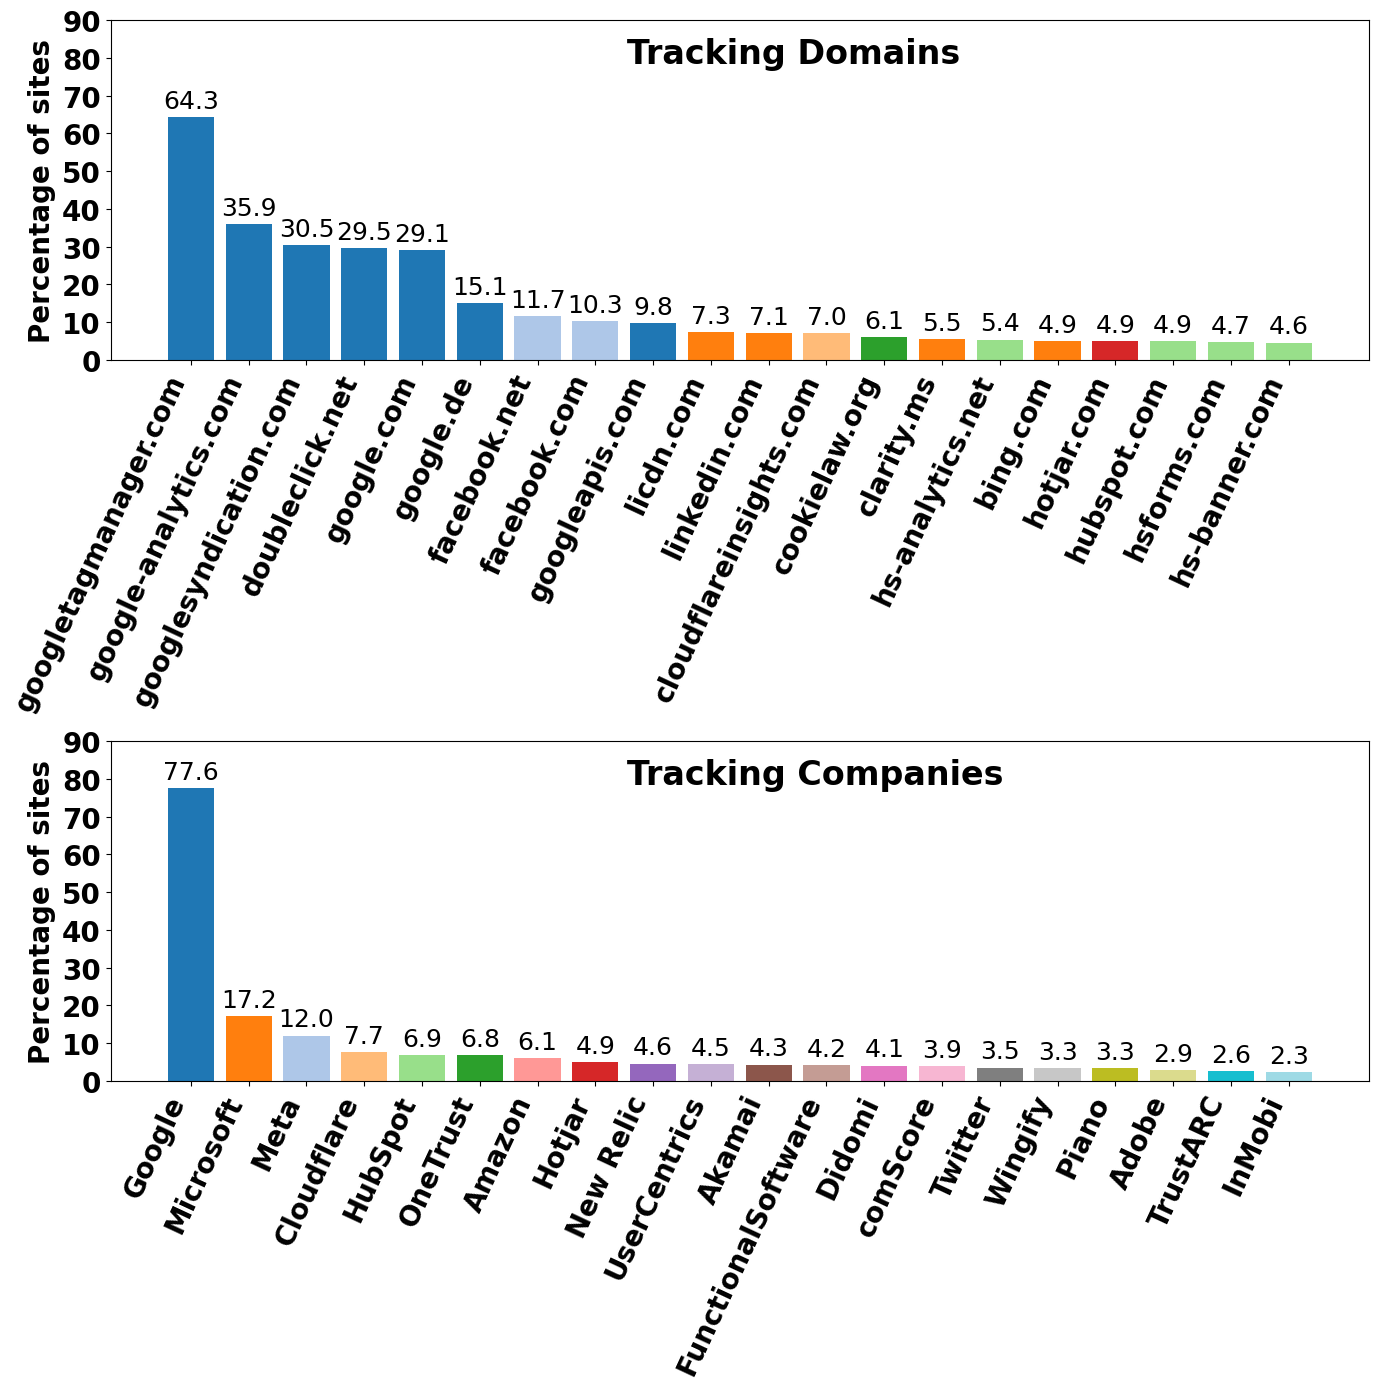

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load CSVs
top20_domains_df = pd.read_csv("top20.csv")  # Columns: Tracking Domain, Number of Websites
top20_companies_df = pd.read_csv("top20_companies.csv")  # Columns: Company, Number of Websites

# Build domain-to-company map
domain_to_company = {
    domain: company
    for company, data in entities.items()
    for domain in data.get("properties", []) + data.get("resources", [])
}
domain_to_company["googletagmanager.com"] = "Google"  # Manual fix

# Map company names to tracking domains
top20_domains_df["Company"] = top20_domains_df["Tracking Domain"].map(domain_to_company)

# Calculate percentages
total = len(domains_without_tracking_cookies)  # Predefined value
print(total)
top20_domains_df["Percentage"] = (top20_domains_df["Number of Websites"] / total) * 100
top20_companies_df["Percentage"] = (top20_companies_df["Number of Websites"] / total) * 100

# Assign consistent colors to companies
all_companies = pd.concat([
    top20_domains_df["Company"],
    top20_companies_df["Company"]
]).dropna().unique()
color_palette = plt.cm.tab20.colors
company_colors = {company: color for company, color in zip(all_companies, color_palette)}
domain_colors = top20_domains_df["Company"].map(company_colors)
company_colors_bar = top20_companies_df["Company"].map(company_colors)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14))

# Plot top tracking domains
x1 = np.arange(len(top20_domains_df))
bars1 = ax1.bar(x1, top20_domains_df["Percentage"], color=domain_colors)
ax1.bar_label(bars1, fmt="%.1f", padding=3, fontsize=18)
ax1.set_ylabel("Percentage of sites", fontsize=20, fontweight="bold")
ax1.set_xticks(x1)
ax1.set_xticklabels(top20_domains_df["Tracking Domain"], rotation=65, ha='right')
ax1.set_ylim(0, 90)
ax1.text(0.41, 0.95, "Tracking Domains", transform=ax1.transAxes,
         fontsize=24, fontweight="bold", va='top', ha='left',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Style y-ticks for ax1
for label in ax1.get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight("bold")
for label in ax1.get_xticklabels():
    label.set_fontsize(20)
    label.set_fontweight("bold")

# Plot top tracking companies
x2 = np.arange(len(top20_companies_df))
bars2 = ax2.bar(x2, top20_companies_df["Percentage"], color=company_colors_bar)
ax2.bar_label(bars2, fmt="%.1f", padding=3, fontsize=18)
ax2.set_ylabel("Percentage of sites", fontsize=20, fontweight="bold")
ax2.set_xticks(x2)
ax2.set_xticklabels(top20_companies_df["Company"], rotation=65, ha='right')
ax2.set_ylim(0, 90)
ax2.text(0.41, 0.95, "Tracking Companies", transform=ax2.transAxes,
         fontsize=24, fontweight="bold", va='top', ha='left',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Style y-ticks for ax2
for label in ax2.get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight("bold")
for label in ax2.get_xticklabels():
    label.set_fontsize(20)
    label.set_fontweight("bold")

plt.tight_layout()
plt.savefig("top20_domains_and_companies_percent.pdf")
plt.show()


137597
137597
15
37
Number of zero entries per disclosure group:
- Cookie-only disclosure: 950
- Cookie-only and vague disclosure: 597
- Broad disclosure: 386
- Vague disclosure: 22
Broad disclosure total_cookie_count values:
[  0   0   0 ... 385 399 400]

Cookie-only and vague disclosure total_cookie_count values:
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0  

/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/1974177762.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(
/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/1974177762.py:160: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(xtick_labels, rotation=60, fontsize=26, fontweight='bold',  ha='right')


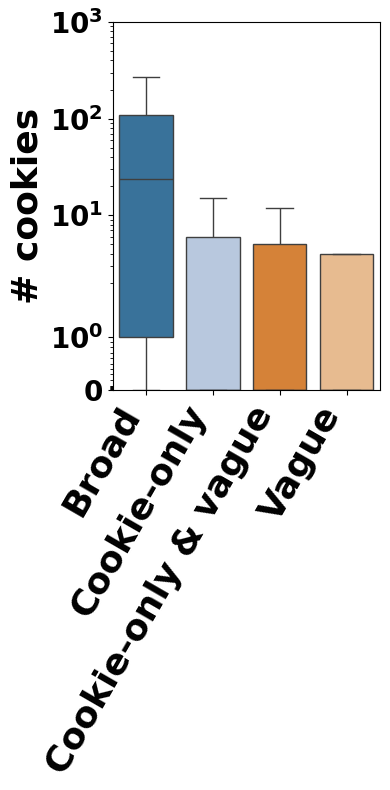

In [238]:
# Need to recheck
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import numpy as np
import pandas as pd

# Define colors for the groups (extend if using 4)
colors = ['#78C850', '#F08030', '#6890F0', '#F8D030']

colors = plt.cm.tab20.colors

common_domains = set(unique_domains_can_analyze_banner)


# Step 1: Filter cookie data for relevant stages and tracking cookies
df_cookie_accept = df_cookie[df_cookie['clicked_stage'].isin([
    'Before Interaction (Accept)',
    'After Interaction (Accept)',
    'After Reload (Accept)'
])]
df_cookie_accept = df_cookie_accept[
    (df_cookie_accept['is_tracking'] == True) &
    (df_cookie_accept['domain_cookie'] != df_cookie_accept['domain']) &
    (df_cookie_accept['domain'].isin(common_domains))
]

# Step 2: Assign disclosure group to each domain
def assign_disclosure_group(domain):
    if domain in cookie_only_and_vague_disclosure:
        return 'Cookie-only and vague disclosure'
    elif domain in cookie_only_disclosure:
        return 'Cookie-only disclosure'
    elif domain in vague_disclosure:
        return 'Vague disclosure'
    elif domain in broad_disclosure:
        return 'Broad disclosure'
    else:
        return None

df_cookie_accept['disclosure_group'] = df_cookie_accept['domain'].apply(assign_disclosure_group)
print (len(df_cookie_accept)) # 129409
df_cookie_accept = df_cookie_accept[df_cookie_accept['disclosure_group'].notnull()]
print (len(df_cookie_accept)) # 126789

cookie_counts = df_cookie_accept.drop_duplicates(
    subset=    ['disclosure_group', 'domain', 'host_url', 'name']
).groupby(
        ['disclosure_group', 'domain', 'host_url', 'name']
).size().reset_index(name='cookie_count')




# Step 3: Count cookies per domain
cookie_counts = df_cookie_accept.groupby(
    ['disclosure_group', 'domain', 'host_url', 'name']
).size().reset_index(name='cookie_count')
# print (cookie_counts)
combined_data = cookie_counts.groupby(
    ['disclosure_group', 'domain']
)['cookie_count'].sum().reset_index(name='total_cookie_count')


print (len(combined_data[combined_data['disclosure_group'] == 'Vague disclosure'])
)
       
print (len(set(vague_disclosure).intersection(common_domains)))


combined_data.to_csv("ali_error_1.csv", index= False)


# Step 5: Add missing domains with cookie_count = 0 for each group
def create_zero_entries(domain_list, group_name):
    missing_domains = list(set(domain_list).intersection(common_domains) - set(combined_data[combined_data['disclosure_group'] == group_name]['domain']))
    return pd.DataFrame({
        'disclosure_group': [group_name] * len(missing_domains),
        'domain': missing_domains,
        'total_cookie_count': [0] * len(missing_domains)
    })

zero_entries = pd.concat([
    create_zero_entries(cookie_only_disclosure, 'Cookie-only disclosure'),
    create_zero_entries(vague_disclosure, 'Vague disclosure'),
    create_zero_entries(cookie_only_and_vague_disclosure, 'Cookie-only and vague disclosure'),
    create_zero_entries(broad_disclosure, 'Broad disclosure'),
], ignore_index=True)

# Print length of zero entries for each disclosure group
group_counts = zero_entries['disclosure_group'].value_counts()

print("Number of zero entries per disclosure group:")
for group, count in group_counts.items():
    print(f"- {group}: {count}")
combined_data = pd.concat([combined_data, zero_entries], ignore_index=True)

# # Compute descriptive statistics for each disclosure group
stats = combined_data.groupby("disclosure_group")["total_cookie_count"].describe()

# Rename and select relevant columns
stats = stats.rename(columns={
    "mean": "Mean",
    "50%": "Median",
    "std": "Std Dev",
    "min": "Min",
    "max": "Max"
})[["count", "Mean", "Std Dev", "Min", "Median", "Max"]]

# Print the result
# print(stats)
# # Step 6: Plot


for group in combined_data['disclosure_group'].unique():
    group_values = combined_data[combined_data['disclosure_group'] == group]['total_cookie_count'].sort_values()
    print(f"{group} total_cookie_count values:\n{group_values.values}\n")
fig, axes = plt.subplots(1, 1, figsize=(4, 8))

order = [
    "Broad disclosure",
    "Cookie-only disclosure",
    "Cookie-only and vague disclosure",
    "Vague disclosure"
    
    
]


bp = sns.boxplot(
    x="disclosure_group",
    y="total_cookie_count",
    data=combined_data,
    order=order,
    palette=colors,
    showfliers=False,
    saturation=0.65,
    ax=axes,
    orient="v"
)

# Customize the plot
# axes.set_title("Cookie Disclosure Types", fontsize=16)
axes.set_ylabel("# cookies", fontsize=26, fontweight='bold')
axes.set_xlabel("", fontsize=20)

axes.set_yscale("symlog")
axes.set_ylim(0, 10**3)

# Modify x-tick labels: replace long label with ampersand version
# Modify x-tick labels: replace long label with ampersand version
xtick_labels = [
    label.get_text()
    .replace("Cookie-only and vague disclosure", "Cookie-only & vague")
    .replace("Cookie-only disclosure", "Cookie-only")
    .replace("Vague disclosure", "Vague")
    .replace("Broad disclosure", "Broad")
    for label in axes.get_xticklabels()
]
axes.set_xticklabels(xtick_labels, rotation=60, fontsize=26, fontweight='bold',  ha='right')

# Style y-axis ticks
axes.tick_params(axis='y', which='both', left=True, labelsize=20)
for label in axes.get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight('bold')

# Set minor ticks for symlog y-axis
axes.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

plt.tight_layout()
plt.savefig("cookie_disclosure_groups.pdf")
plt.show()


137597
137597
Number of zero entries per disclosure group:
- Cookie-only disclosure: 950
- Cookie-only and vague disclosure: 597
- Broad disclosure: 386
- Vague disclosure: 22
                                   count       Mean    Std Dev  Min  Median  \
disclosure_group                                                              
Broad disclosure                  1832.0  63.727620  77.859412  0.0    24.0   
Cookie-only and vague disclosure   948.0  12.395570  39.076735  0.0     0.0   
Cookie-only disclosure            1693.0   5.191376  11.637654  0.0     0.0   
Vague disclosure                    37.0   6.297297  11.445195  0.0     0.0   

                                    Max  
disclosure_group                         
Broad disclosure                  400.0  
Cookie-only and vague disclosure  397.0  
Cookie-only disclosure            169.0  
Vague disclosure                   41.0  
Broad disclosure total_cookie_count values:
[  0   0   0 ... 385 399 400]

Cookie-only and vague 

/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/1631833126.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(
/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/1631833126.py:147: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(xtick_labels, rotation=60, fontsize=26, fontweight='bold',  ha='right')


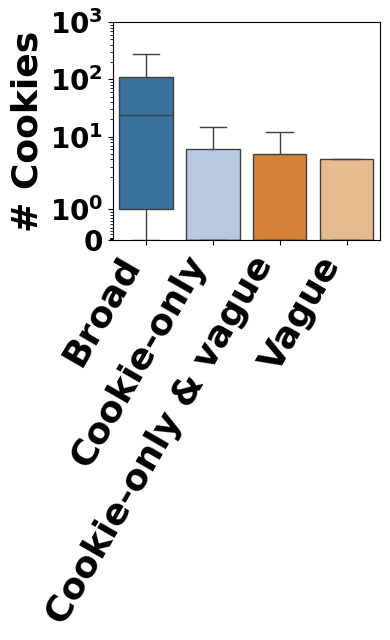

In [299]:
# Need to recheck
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import numpy as np
import pandas as pd

# Define colors for the groups (extend if using 4)
colors = ['#78C850', '#F08030', '#6890F0', '#F8D030']

colors = plt.cm.tab20.colors

# Step 1: Filter cookie data for relevant stages and tracking cookies
df_cookie_accept = df_cookie[df_cookie['clicked_stage'].isin([
    'Before Interaction (Accept)',
    'After Interaction (Accept)',
    'After Reload (Accept)'
])]
df_cookie_accept = df_cookie_accept[
    (df_cookie_accept['is_tracking'] == True) &
    (df_cookie_accept['domain_cookie'] != df_cookie_accept['domain']) &
    (df_cookie_accept['domain'].isin(common_domains))
]

# Step 2: Assign disclosure group to each domain
def assign_disclosure_group(domain):
    if domain in cookie_only_and_vague_disclosure:
        return 'Cookie-only and vague disclosure'
    elif domain in cookie_only_disclosure:
        return 'Cookie-only disclosure'
    elif domain in vague_disclosure:
        return 'Vague disclosure'
    elif domain in broad_disclosure:
        return 'Broad disclosure'
    else:
        return None

df_cookie_accept['disclosure_group'] = df_cookie_accept['domain'].apply(assign_disclosure_group)
print (len(df_cookie_accept)) # 129409
df_cookie_accept = df_cookie_accept[df_cookie_accept['disclosure_group'].notnull()]
print (len(df_cookie_accept)) # 126789

cookie_counts = df_cookie_accept.drop_duplicates(
    subset=    ['disclosure_group', 'domain', 'host_url', 'name']
).groupby(
        ['disclosure_group', 'domain', 'host_url', 'name']
).size().reset_index(name='cookie_count')




# Step 3: Count cookies per domain
cookie_counts = df_cookie_accept.groupby(
    ['disclosure_group', 'domain', 'host_url', 'name']
).size().reset_index(name='cookie_count')
# print (cookie_counts)
combined_data = cookie_counts.groupby(
    ['disclosure_group', 'domain']
)['cookie_count'].sum().reset_index(name='total_cookie_count')

# Step 5: Add missing domains with cookie_count = 0 for each group
def create_zero_entries(domain_list, group_name):
    missing_domains = list(set(domain_list).intersection(common_domains) - set(combined_data[combined_data['disclosure_group'] == group_name]['domain']))
    return pd.DataFrame({
        'disclosure_group': [group_name] * len(missing_domains),
        'domain': missing_domains,
        'total_cookie_count': [0] * len(missing_domains)
    })

zero_entries = pd.concat([
    create_zero_entries(cookie_only_disclosure, 'Cookie-only disclosure'),
    create_zero_entries(vague_disclosure, 'Vague disclosure'),
    create_zero_entries(cookie_only_and_vague_disclosure, 'Cookie-only and vague disclosure'),
    create_zero_entries(broad_disclosure, 'Broad disclosure'),
], ignore_index=True)

# Print length of zero entries for each disclosure group
group_counts = zero_entries['disclosure_group'].value_counts()

print("Number of zero entries per disclosure group:")
for group, count in group_counts.items():
    print(f"- {group}: {count}")
combined_data = pd.concat([combined_data, zero_entries], ignore_index=True)

# Compute descriptive statistics for each disclosure group
stats = combined_data.groupby("disclosure_group")["total_cookie_count"].describe()

# Rename and select relevant columns
stats = stats.rename(columns={
    "mean": "Mean",
    "50%": "Median",
    "std": "Std Dev",
    "min": "Min",
    "max": "Max"
})[["count", "Mean", "Std Dev", "Min", "Median", "Max"]]

# Print the result
print(stats)
# Step 6: Plot


for group in combined_data['disclosure_group'].unique():
    group_values = combined_data[combined_data['disclosure_group'] == group]['total_cookie_count'].sort_values()
    print(f"{group} total_cookie_count values:\n{group_values.values}\n")
fig, axes = plt.subplots(1, 1, figsize=(4, 6.5))

order = [
    "Broad disclosure",
    "Cookie-only disclosure",
    "Cookie-only and vague disclosure",
    "Vague disclosure"
    
    
]


bp = sns.boxplot(
    x="disclosure_group",
    y="total_cookie_count",
    data=combined_data,
    order=order,
    palette=colors,
    showfliers=False,
    saturation=0.65,
    ax=axes,
    orient="v"
)

# Customize the plot
# axes.set_title("Cookie Disclosure Types", fontsize=16)
axes.set_ylabel("# Cookies", fontsize=26, fontweight='bold')
axes.set_xlabel("", fontsize=20)

axes.set_yscale("symlog")
axes.set_ylim(0, 10**3)

# Modify x-tick labels: replace long label with ampersand version
# Modify x-tick labels: replace long label with ampersand version
xtick_labels = [
    label.get_text()
    .replace("Cookie-only and vague disclosure", "Cookie-only & vague")
    .replace("Cookie-only disclosure", "Cookie-only")
    .replace("Vague disclosure", "Vague")
    .replace("Broad disclosure", "Broad")
    for label in axes.get_xticklabels()
]
axes.set_xticklabels(xtick_labels, rotation=60, fontsize=26, fontweight='bold',  ha='right')

# Style y-axis ticks
axes.tick_params(axis='y', which='both', left=True, labelsize=20)
for label in axes.get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight('bold')

# Set minor ticks for symlog y-axis
axes.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

plt.tight_layout()
plt.savefig("cookie_disclosure_groups.pdf")
plt.show()


Number of zero entries per disclosure group:
- Cookie-only disclosure: 121
- Broad disclosure: 98
- Cookie-only and vague disclosure: 84
- Vague disclosure: 8
                                   count        Mean     Std Dev  Min  Median  \
disclosure_group                                                                
Broad disclosure                  1930.0  267.054922  276.725761  0.0   161.0   
Cookie-only and vague disclosure  1032.0   71.856589  147.592233  0.0    22.0   
Cookie-only disclosure            1814.0   57.699008   63.950415  0.0    41.0   
Vague disclosure                    45.0   54.466667   74.530226  0.0    18.0   

                                     Max  
disclosure_group                          
Broad disclosure                  1662.0  
Cookie-only and vague disclosure  1379.0  
Cookie-only disclosure             712.0  
Vague disclosure                   293.0  
Domain with highest total_request_count:
disclosure_group       Broad disclosure
domain         

/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/1235304533.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(
/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/1235304533.py:152: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(xtick_labels, rotation=60, fontsize=26, fontweight='bold',  ha='right')


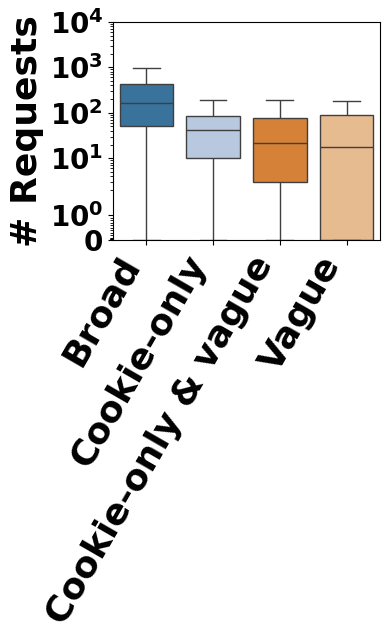

In [241]:

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import numpy as np
import pandas as pd

# Define colors for the groups (extend if using 4)
colors = ['#78C850', '#F08030', '#6890F0', '#F8D030']
colors = plt.cm.tab20.colors

# df_request =  pd.read_csv("request_sample.csv")
# df_request['domain_url'] = df_request['host_url'].apply(lambda url: tldextract.extract(url).registered_domain)

# df_request = df_request[df_request["clicked"]!="nan"]
# df_request["clicked_stage"] = df_request["stage"] + " (" + df_request["clicked"].str.capitalize() + ")"


# Step 1: Filter request data for relevant stages and matching requests
df_request_accept = df_request[df_request['clicked_stage'].isin([
    'Before Interaction (Accept)',
    'After Interaction (Accept)',
    'After Reload (Accept)'
])]
df_request_accept = df_request_accept[
    (df_request_accept['AllList'] == True) &
    (df_request_accept['domain_url'] != df_request_accept['domain']) & 
    (df_request_accept['domain'].isin(common_domains))
]

# Step 2: Assign disclosure group to each domain
def assign_disclosure_group(domain):
    if domain in cookie_only_and_vague_disclosure:
        return 'Cookie-only and vague disclosure'
    elif domain in cookie_only_disclosure:
        return 'Cookie-only disclosure'
    elif domain in vague_disclosure:
        return 'Vague disclosure'
    elif domain in broad_disclosure:
        return 'Broad disclosure'
    else:
        return None

df_request_accept['disclosure_group'] = df_request_accept['domain'].apply(assign_disclosure_group)
df_request_accept = df_request_accept[df_request_accept['disclosure_group'].notnull()]

# Step 3: Count requests per domain
# request_counts = df_request_accept.groupby(
#     ['disclosure_group', 'domain', 'host_url']
# ).size().reset_index(name='request_count')

request_counts = df_request_accept.drop_duplicates(
    subset=['disclosure_group', 'domain', 'host_url']
).groupby(
    ['disclosure_group', 'domain', 'host_url']
).size().reset_index(name='request_count')


# print (request_counts)
combined_data = request_counts.groupby(
    ['disclosure_group', 'domain']
)['request_count'].sum().reset_index(name='total_request_count')


# Step 5: Add missing domains with request_count = 0 for each group
def create_zero_entries(domain_list, group_name):
    missing_domains = list(set(domain_list).intersection(common_domains) - set(combined_data[combined_data['disclosure_group'] == group_name]['domain']))
    return pd.DataFrame({
        'disclosure_group': [group_name] * len(missing_domains),
        'domain': missing_domains,
        'total_request_count': [0] * len(missing_domains)
    })

zero_entries = pd.concat([
    create_zero_entries(cookie_only_disclosure, 'Cookie-only disclosure'),
    create_zero_entries(vague_disclosure, 'Vague disclosure'),
    create_zero_entries(cookie_only_and_vague_disclosure, 'Cookie-only and vague disclosure'),
    create_zero_entries(broad_disclosure, 'Broad disclosure'),
], ignore_index=True)

# Print length of zero entries for each disclosure group
group_counts = zero_entries['disclosure_group'].value_counts()

print("Number of zero entries per disclosure group:")
for group, count in group_counts.items():
    print(f"- {group}: {count}")
combined_data = pd.concat([combined_data, zero_entries], ignore_index=True)


combined_data = pd.concat([combined_data, zero_entries], ignore_index=True)

# print (combined_data)

# Compute descriptive statistics for each disclosure group
stats = combined_data.groupby("disclosure_group")["total_request_count"].describe()

# Rename and select relevant columns
stats = stats.rename(columns={
    "mean": "Mean",
    "50%": "Median",
    "std": "Std Dev",
    "min": "Min",
    "max": "Max"
})[["count", "Mean", "Std Dev", "Min", "Median", "Max"]]

# Print the result
print(stats)

max_domain = combined_data.loc[combined_data['total_request_count'].idxmax()]
print("Domain with highest total_request_count:")
print(max_domain)
# Step 6: Plot
fig, axes = plt.subplots(1, 1, figsize=(4, 6.5))

order = [
    "Broad disclosure",
    "Cookie-only disclosure",
    "Cookie-only and vague disclosure",
    "Vague disclosure"
    
    
]


bp = sns.boxplot(
    x="disclosure_group",
    y="total_request_count",
    data=combined_data,
    order=order,
    palette=colors,
    showfliers=False,
    saturation=0.65,
    ax=axes,
    orient="v"
)


axes.set_ylabel("# Requests", fontsize=26, fontweight='bold')
axes.set_xlabel("")
axes.set_yscale("symlog")
axes.set_ylim(0, 10**4)

# Modify x-tick labels: replace long label with ampersand version
# Modify x-tick labels: replace long label with ampersand version
xtick_labels = [
    label.get_text()
    .replace("Cookie-only and vague disclosure", "Cookie-only & vague")
    .replace("Cookie-only disclosure", "Cookie-only")
    .replace("Vague disclosure", "Vague")
    .replace("Broad disclosure", "Broad")
    for label in axes.get_xticklabels()
]
axes.set_xticklabels(xtick_labels, rotation=60, fontsize=26, fontweight='bold',  ha='right')

# Style y-axis ticks
axes.tick_params(axis='y', which='both', left=True, labelsize=20)
for label in axes.get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight('bold')

# Set minor ticks for symlog y-axis
axes.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

plt.tight_layout()
plt.savefig("3rd_tracking_requests_disclosure_groups.pdf")
plt.show()


1161
Number of zero entries per disclosure group:
- Cookie-only disclosure: 492
- Cookie-only and vague disclosure: 427
- Broad disclosure: 226
- Vague disclosure: 16
                                   count       Mean   Std Dev  Min  Median  \
disclosure_group                                                             
Broad disclosure                  1832.0  12.597707  9.154315  0.0    12.0   
Cookie-only and vague disclosure   948.0   3.599156  7.053700  0.0     1.0   
Cookie-only disclosure            1693.0   3.191967  3.862486  0.0     2.0   
Vague disclosure                    37.0   2.945946  4.557935  0.0     1.0   

                                    Max  
disclosure_group                         
Broad disclosure                   61.0  
Cookie-only and vague disclosure  111.0  
Cookie-only disclosure             49.0  
Vague disclosure                   20.0  


/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/2387528314.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(
/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/2387528314.py:140: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(xtick_labels, rotation=60, fontsize=26, fontweight='bold',  ha='right')


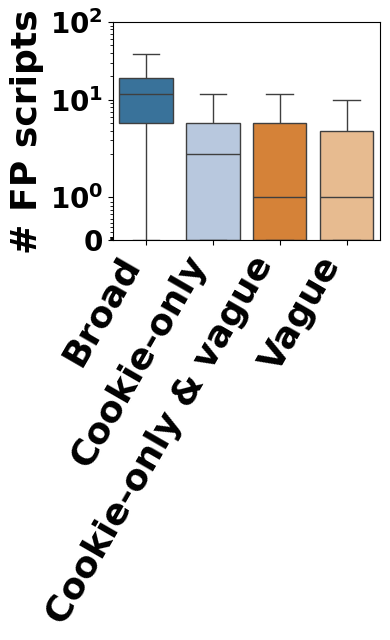

In [240]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import numpy as np
import pandas as pd

# Define colors for the groups (extend if using 4)
colors = ['#78C850', '#F08030', '#6890F0', '#F8D030']
colors = plt.cm.tab20.colors
# Step 1: Filter request data for relevant stages and matching requests
df_javascript_accept = df_javascript[df_javascript['clicked_stage'].isin([
    'Before Interaction (Accept)',
    'After Interaction (Accept)',
    'After Reload (Accept)'
])]

# Optional: View result
df_javascript_accept = df_javascript_accept[
    (df_javascript_accept['AllList'] == True) & 
    ((df_javascript_accept['FingerprintingInvasive'] == True) | (df_javascript_accept['FingerprintingGeneral'] == True)) & 
    (df_javascript_accept['domain_script_url'] != df_javascript_accept['domain']) &
     (df_javascript_accept['domain'].isin(common_domains))
    
]


# Step 2: Assign disclosure group to each domain
def assign_disclosure_group(domain):
    if domain in cookie_only_and_vague_disclosure:
        return 'Cookie-only and vague disclosure'
    elif domain in cookie_only_disclosure:
        return 'Cookie-only disclosure'
    elif domain in vague_disclosure:
        return 'Vague disclosure'
    elif domain in broad_disclosure:
        return 'Broad disclosure'
    else:
        return None

df_javascript_accept['disclosure_group'] = df_javascript_accept['domain'].apply(assign_disclosure_group)
df_javascript_accept = df_javascript_accept[df_javascript_accept['disclosure_group'].notnull()]

# # Step 3: Count requests per domain
# request_counts = df_javascript_accept.drop_duplicates(
#     subset=['disclosure_group', 'domain', 'domain_script_url']
# ).groupby(
#     ['disclosure_group', 'domain', 'domain_script_url']
# ).size().reset_index(name='request_count')

request_counts = df_javascript_accept.drop_duplicates(
    subset=['disclosure_group', 'domain', 'host_url']
).groupby(
    ['disclosure_group', 'domain', 'host_url']
).size().reset_index(name='request_count')

combined_data = request_counts.groupby(
    ['disclosure_group', 'domain']
)['request_count'].sum().reset_index(name='total_request_count')

# Step 5: Add missing domains with request_count = 0 for each group
def create_zero_entries(domain_list, group_name):
    missing_domains = list(set(domain_list).intersection(common_domains) - set(combined_data[combined_data['disclosure_group'] == group_name]['domain']))
    return pd.DataFrame({
        'disclosure_group': [group_name] * len(missing_domains),
        'domain': missing_domains,
        'total_request_count': [0] * len(missing_domains)
    })

zero_entries = pd.concat([
    create_zero_entries(cookie_only_disclosure, 'Cookie-only disclosure'),
    create_zero_entries(vague_disclosure, 'Vague disclosure'),
    create_zero_entries(cookie_only_and_vague_disclosure, 'Cookie-only and vague disclosure'),
    create_zero_entries(broad_disclosure, 'Broad disclosure'),
], ignore_index=True)

print(len(zero_entries))
# Print length of zero entries for each disclosure group
group_counts = zero_entries['disclosure_group'].value_counts()

print("Number of zero entries per disclosure group:")
for group, count in group_counts.items():
    print(f"- {group}: {count}")
combined_data = pd.concat([combined_data, zero_entries], ignore_index=True)

# Compute descriptive statistics for each disclosure group
stats = combined_data.groupby("disclosure_group")["total_request_count"].describe()

# Rename and select relevant columns
stats = stats.rename(columns={
    "mean": "Mean",
    "50%": "Median",
    "std": "Std Dev",
    "min": "Min",
    "max": "Max"
})[["count", "Mean", "Std Dev", "Min", "Median", "Max"]]

# Print the result
print(stats)
# Step 6: Plot
fig, axes = plt.subplots(1, 1, figsize=(4, 6.5))

order = [
    "Broad disclosure",
    "Cookie-only disclosure",
    "Cookie-only and vague disclosure",
    "Vague disclosure"
    
    
]


bp = sns.boxplot(
    x="disclosure_group",
    y="total_request_count",
    data=combined_data,
    order=order,
    palette=colors,
    showfliers=False,
    saturation=0.65,
    ax=axes,
    orient="v"
)

# Customize the plot
axes.set_ylabel("# FP scripts", fontsize=26, fontweight='bold')
axes.set_xlabel("")
axes.set_yscale("symlog")
axes.set_ylim(0, 10**2)

# Modify x-tick labels: replace long label with ampersand version
xtick_labels = [
    label.get_text()
    .replace("Cookie-only and vague disclosure", "Cookie-only & vague")
    .replace("Cookie-only disclosure", "Cookie-only")
    .replace("Vague disclosure", "Vague")
    .replace("Broad disclosure", "Broad")
    for label in axes.get_xticklabels()
]

axes.set_xticklabels(xtick_labels, rotation=60, fontsize=26, fontweight='bold',  ha='right')

# Style y-axis ticks
axes.tick_params(axis='y', which='both', left=True, labelsize=20)
for label in axes.get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight('bold')

# Set minor ticks for symlog y-axis
axes.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

plt.tight_layout()
plt.savefig("3rd_fingerprinting_scripts_domain_disclosure_groups.pdf")
plt.show()


/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/3288627375.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/3288627375.py:167: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/3288627375.py:183: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/3288627375.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks,

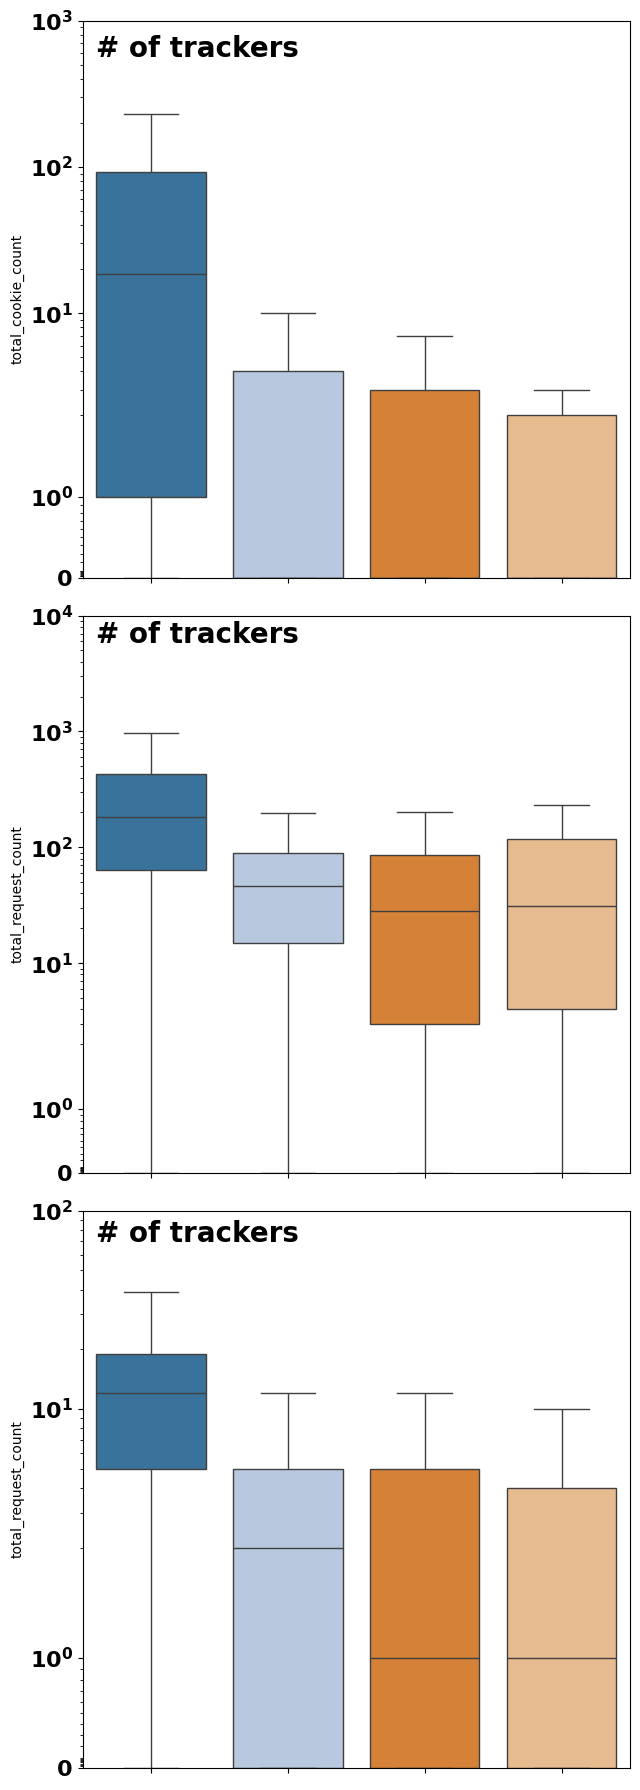

In [245]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import numpy as np
import pandas as pd

# Define colors and order
colors = plt.cm.tab20.colors
order = [
    "Broad disclosure",
    "Cookie-only disclosure",
    "Cookie-only and vague disclosure",
    "Vague disclosure"
]

# --- Helper functions ---

def assign_disclosure_group(domain):
    if domain in cookie_only_and_vague_disclosure:
        return 'Cookie-only and vague disclosure'
    elif domain in cookie_only_disclosure:
        return 'Cookie-only disclosure'
    elif domain in vague_disclosure:
        return 'Vague disclosure'
    elif domain in broad_disclosure:
        return 'Broad disclosure'
    else:
        return None

def create_zero_entries(domain_list, group_name, existing_df, colname='total_request_count'):
    missing_domains = list(set(domain_list).intersection(common_domains) - set(existing_df[existing_df['disclosure_group'] == group_name]['domain']))
    return pd.DataFrame({
        'disclosure_group': [group_name] * len(missing_domains),
        'domain': missing_domains,
        colname: [0] * len(missing_domains)
    })

def format_xticks(ax):
    xtick_labels = [
        label.get_text()
        .replace("Cookie-only and vague disclosure", "Cookie-only & vague")
        .replace("Cookie-only disclosure", "Cookie-only")
        .replace("Vague disclosure", "Vague")
        .replace("Broad disclosure", "Broad")
        for label in ax.get_xticklabels()
    ]
    ax.set_xticklabels(xtick_labels, rotation=60, fontsize=18, fontweight='bold', ha='right')
    ax.tick_params(axis='y', which='both', left=True, labelsize=16)
    for label in ax.get_yticklabels():
        label.set_fontsize(16)
        label.set_fontweight('bold')
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
    ax.set_xlabel("")


# --- Process df_cookie ---
df_cookie_accept = df_cookie[df_cookie['clicked_stage'].isin([
    'Before Interaction (Accept)',
    'After Interaction (Accept)',
    'After Reload (Accept)'
])]
df_cookie_accept = df_cookie_accept[
    (df_cookie_accept['is_tracking'] == True) &
    (df_cookie_accept['domain_cookie'] != df_cookie_accept['domain']) &
    (df_cookie_accept['domain'].isin(common_domains))
]
df_cookie_accept['disclosure_group'] = df_cookie_accept['domain'].apply(assign_disclosure_group)
df_cookie_accept = df_cookie_accept[df_cookie_accept['disclosure_group'].notnull()]

cookie_counts = df_cookie_accept.drop_duplicates(
    subset=['disclosure_group', 'domain', 'host_url', 'name']
).groupby(['disclosure_group', 'domain', 'host_url', 'name']).size().reset_index(name='cookie_count')

combined_data_cookie = cookie_counts.groupby(['disclosure_group', 'domain'])['cookie_count'].sum().reset_index(name='total_cookie_count')

zero_entries_cookie = pd.concat([
    create_zero_entries(cookie_only_disclosure, 'Cookie-only disclosure', combined_data_cookie, 'total_cookie_count'),
    create_zero_entries(vague_disclosure, 'Vague disclosure', combined_data_cookie, 'total_cookie_count'),
    create_zero_entries(cookie_only_and_vague_disclosure, 'Cookie-only and vague disclosure', combined_data_cookie, 'total_cookie_count'),
    create_zero_entries(broad_disclosure, 'Broad disclosure', combined_data_cookie, 'total_cookie_count'),
], ignore_index=True)

combined_data_cookie = pd.concat([combined_data_cookie, zero_entries_cookie], ignore_index=True)


# --- Process df_request ---
df_request_accept = df_request[df_request['clicked_stage'].isin([
    'Before Interaction (Accept)',
    'After Interaction (Accept)',
    'After Reload (Accept)'
])]
df_request_accept = df_request_accept[
    (df_request_accept['AllList'] == True) &
    (df_request_accept['domain_url'] != df_request_accept['domain']) & 
    (df_request_accept['domain'].isin(common_domains))
]
df_request_accept['disclosure_group'] = df_request_accept['domain'].apply(assign_disclosure_group)
df_request_accept = df_request_accept[df_request_accept['disclosure_group'].notnull()]

request_counts = df_request_accept.drop_duplicates(
    subset=['disclosure_group', 'domain', 'host_url']
).groupby(['disclosure_group', 'domain', 'host_url']).size().reset_index(name='request_count')

combined_data_requests = request_counts.groupby(['disclosure_group', 'domain'])['request_count'].sum().reset_index(name='total_request_count')

zero_entries_requests = pd.concat([
    create_zero_entries(cookie_only_disclosure, 'Cookie-only disclosure', combined_data_requests),
    create_zero_entries(vague_disclosure, 'Vague disclosure', combined_data_requests),
    create_zero_entries(cookie_only_and_vague_disclosure, 'Cookie-only and vague disclosure', combined_data_requests),
    create_zero_entries(broad_disclosure, 'Broad disclosure', combined_data_requests),
], ignore_index=True)

combined_data_requests = pd.concat([combined_data_requests, zero_entries_requests], ignore_index=True)


# --- Process df_javascript ---
df_javascript_accept = df_javascript[df_javascript['clicked_stage'].isin([
    'Before Interaction (Accept)',
    'After Interaction (Accept)',
    'After Reload (Accept)'
])]
df_javascript_accept = df_javascript_accept[
    (df_javascript_accept['AllList'] == True) &
    ((df_javascript_accept['FingerprintingInvasive'] == True) | (df_javascript_accept['FingerprintingGeneral'] == True)) &
    (df_javascript_accept['domain_script_url'] != df_javascript_accept['domain']) &
    (df_javascript_accept['domain'].isin(common_domains))
]
df_javascript_accept['disclosure_group'] = df_javascript_accept['domain'].apply(assign_disclosure_group)
df_javascript_accept = df_javascript_accept[df_javascript_accept['disclosure_group'].notnull()]

fp_counts = df_javascript_accept.drop_duplicates(
    subset=['disclosure_group', 'domain', 'host_url']
).groupby(['disclosure_group', 'domain', 'host_url']).size().reset_index(name='request_count')

combined_data_fp_scripts = fp_counts.groupby(['disclosure_group', 'domain'])['request_count'].sum().reset_index(name='total_request_count')

zero_entries_fp = pd.concat([
    create_zero_entries(cookie_only_disclosure, 'Cookie-only disclosure', combined_data_fp_scripts),
    create_zero_entries(vague_disclosure, 'Vague disclosure', combined_data_fp_scripts),
    create_zero_entries(cookie_only_and_vague_disclosure, 'Cookie-only and vague disclosure', combined_data_fp_scripts),
    create_zero_entries(broad_disclosure, 'Broad disclosure', combined_data_fp_scripts),
], ignore_index=True)

combined_data_fp_scripts = pd.concat([combined_data_fp_scripts, zero_entries_fp], ignore_index=True)






/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/2710123152.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/2710123152.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels, rotation=50, fontsize=24, fontweight='bold', ha='right')
/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/2710123152.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/63/6wx0622j25g0qlsd7lvm8_9h0000gn/T/ipykernel_926/2710123152.py:26: UserWarning: set_ticklabels() should only be used with a fix

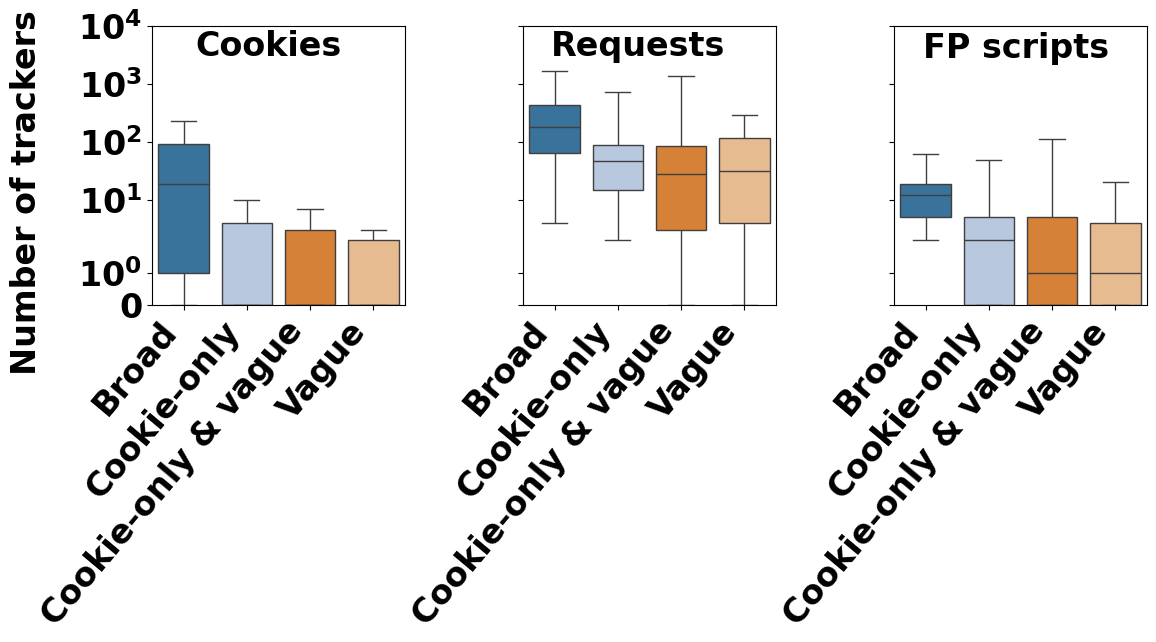

In [297]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import numpy as np

# --- Disclosure groups ---
disclosure_order = [
    "Broad disclosure",
    "Cookie-only disclosure",
    "Cookie-only and vague disclosure",
    "Vague disclosure"
]
disclosure_labels = {
    "Broad disclosure": "Broad",
    "Cookie-only disclosure": "Cookie-only",
    "Cookie-only and vague disclosure": "Cookie-only & vague",
    "Vague disclosure": "Vague"
}
colors = plt.cm.tab20.colors
color_map = dict(zip(disclosure_order, colors[:len(disclosure_order)]))

# --- Format function (removes subplot y-label) ---
def format_axes(ax, y_max):
    ax.set_ylabel("")  # Remove default ylabel like 'total_cookie_count'
    xtick_labels = [disclosure_labels.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()]
    ax.set_xticklabels(xtick_labels, rotation=50, fontsize=24, fontweight='bold', ha='right')
    ax.tick_params(axis='y', which='both', left=True, labelsize=24)
    for label in ax.get_yticklabels():
        label.set_fontsize(24)
        label.set_fontweight('bold')
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
    ax.set_xlabel("")
    ax.set_ylim(0, y_max)
    ax.set_yscale("symlog")

# --- Create subplots ---
fig, axes = plt.subplots(1, 3, figsize=(12, 6.5), sharey=True)

# Shared y-axis label
fig.text(0.04, 0.7, "Number of trackers", va='center', rotation='vertical', fontsize=24, fontweight='bold')

# --- Subplot 1: Cookies ---
sns.boxplot(
    x="disclosure_group",
    y="total_cookie_count",
    data=combined_data_cookie,
    order=disclosure_order,
    palette=color_map,
    showfliers=False,
    saturation=0.65,
    ax=axes[0]
)
format_axes(axes[0], 10**4)
axes[0].text(2.5, 8500, "Cookies", fontsize=24, fontweight="bold", va="top", ha="right")

# --- Subplot 2: Requests ---
sns.boxplot(
    x="disclosure_group",
    y="total_request_count",
    data=combined_data_requests,
    order=disclosure_order,
    palette=color_map,
    showfliers=False,
    saturation=0.65,
    ax=axes[1]
)
format_axes(axes[1], 10**4)
axes[1].text(2.7, 8500, "Requests", fontsize=24, fontweight="bold", va="top", ha="right")

# --- Subplot 3: FP Scripts ---
sns.boxplot(
    x="disclosure_group",
    y="total_request_count",
    data=combined_data_fp_scripts,
    order=disclosure_order,
    palette=color_map,
    showfliers=False,
    saturation=0.65,
    ax=axes[2]
)
format_axes(axes[2], 10**4)
axes[2].text(2.9, 8000, "FP scripts", fontsize=24, fontweight="bold", va="top", ha="right")

# Final layout
plt.tight_layout(rect=[0.06, 0, 1, 1])  # Leave space on the left for shared y-axis label
plt.savefig("behavior_disclosure.pdf")
plt.show()
